## Detecting outliers and adapting models to these

In [1]:
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

from pinard import utils
from pinard import preprocessing as pp
from pinard.model_selection import train_test_split_idx

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
simplefilter(action='ignore', category=UserWarning)

### Importation of the datasets

In [13]:
# Function to load a CSV file with automatic separator detection

def load_csv_auto_sep(mode, data_source, type_data, verbose=True):
 
    # Regression: 'BeerOriginalExtract' or 'Digest_0.8' or 'YamProtein' //
    # Classification: 'CoffeeSpecies' or 'Malaria2024' or 'mDigest_custom3' or 'WhiskyConcentration' or 'YamMould'

    ## Importation of the datasets with the adapted path
    file_name = Path("Data/%s/%s"% (mode,data_source))
    full_path = str(file_name.resolve()).replace("\\", "/")
    path = full_path + "/%s.csv" % type_data

    with open(path, 'r', newline='', encoding='utf-8') as f:
        # Read a small portion of the file to detect the separator
        excerpt = f.read(1024)
        f.seek(0)  # return to the beginning of the file

        # Detection of the dialect
        dialect = csv.Sniffer().sniff(excerpt)
        sep = dialect.delimiter

        if verbose: print("Detected separator : %s" % sep)
        
        # Load the file with pandas
        df = pd.read_csv(f, delimiter=sep)

        if type_data[0]=='Y' and len(df.columns) > 1:
            # Drop the useless column if it exists
            df = df.drop(columns=[df.columns[1]])
        
        return df

In [155]:
mode = 'Regression'
data_source = 'BeerOriginalExtract'

Xcal = load_csv_auto_sep(mode=mode, data_source=data_source, type_data='Xcal')
Xval = load_csv_auto_sep(mode=mode, data_source=data_source, type_data='Xval')
Ycal = load_csv_auto_sep(mode=mode, data_source=data_source, type_data='Ycal')
Yval = load_csv_auto_sep(mode=mode, data_source=data_source, type_data='Yval')

print("Number of spectra for calibration: ", len(Ycal))
print("Number of spectra for test: ", len(Yval))
display(Xcal.head(5))

Detected separator : ;
Detected separator : ;
Detected separator : 
Detected separator : 
Number of spectra for calibration:  40
Number of spectra for test:  20


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V567,V568,V569,V570,V571,V572,V573,V574,V575,V576
0,0.245288,0.251593,0.258437,0.265449,0.272342,0.280249,0.288323,0.297118,0.307861,0.319456,...,3.679895,3.654557,3.653983,3.714209,3.669642,3.625521,3.647152,3.573585,3.623088,3.679775
1,0.242613,0.248841,0.255609,0.262486,0.269311,0.277092,0.285063,0.293715,0.304371,0.315839,...,3.632740,3.738945,3.601677,3.592955,3.606268,3.657218,3.632019,3.660901,3.635919,3.671539
2,0.241651,0.247774,0.254431,0.261214,0.267891,0.275535,0.283370,0.291886,0.302335,0.313625,...,3.563812,3.622122,3.617598,3.652315,3.590150,3.710362,3.630672,3.653063,3.566837,3.704355
3,0.239650,0.245743,0.252350,0.259107,0.265761,0.273390,0.281214,0.289725,0.300164,0.311455,...,3.583575,3.620621,3.682378,3.681044,3.650404,3.645983,3.633222,3.668727,3.650432,3.687260
4,0.240787,0.246900,0.253521,0.260278,0.266935,0.274576,0.282420,0.290953,0.301394,0.312720,...,3.650906,3.728940,3.614735,3.618842,3.656746,3.622961,3.560679,3.710902,3.653769,3.663029


### Construction of the pipelines

In [156]:
rd_seed = 42
rd_seed = np.random.seed(rd_seed)

x, y = pd.concat([Xcal,Xval], axis=0).values, pd.concat([Ycal,Yval], axis=0).values

### Declare preprocessing methods that will be used
preprocessing = [   ('id', pp.IdentityTransformer()),
                    ('baseline', pp.Baseline()),
                    ('derivate', pp.Derivate()),
                    ('detrend', pp.Detrend()),
                    ('MSC', pp.MultiplicativeScatterCorrection()),
                    ('normalize', pp.Normalize()),
                    ('RNV', pp.RobustNormalVariate()),
                    ('savgol', pp.SavitzkyGolay()),
                    ('simplescale', pp.SimpleScale()),
                    ('SNV', pp.StandardNormalVariate()),
                    ('haar', pp.Wavelet('haar')),
                    ('gaussian', pp.Gaussian(order = 2, sigma = 1)),
                    ('PCA', PCA())
                ]

# Apply the preprocessing methods to the calibration dataset
transformed_datasets = {}
for name, method in preprocessing:
    x = method.fit_transform(Xcal)
    transformed_datasets[name] = x

### Detection of outliers with PCA

In [ ]:
scaler = StandardScaler(with_std=False)
dict_outliers = {}
for name, method in preprocessing:
    x = transformed_datasets[name]
    X_scaled = scaler.fit_transform(x)

    # Perform PCA on the scaled data
    X_pca = PCA(n_components=1).fit_transform(X_scaled)

    # Store the PCA scores in a DataFrame for easier manipulation
    scores_df = pd.DataFrame(X_pca, columns=['PC1'])

    # Compute the bounds for extreme individuals
    mean_PC1 = scores_df['PC1'].mean()
    std_PC1 = scores_df['PC1'].std()
    lower_bound = mean_PC1 - 2 * std_PC1
    upper_bound = mean_PC1 + 2 * std_PC1

    # Filter the extreme individuals based on the bounds
    outliers = scores_df[
        (scores_df['PC1'] < lower_bound) | (scores_df['PC1'] > upper_bound)
    ]
    
    # Store the extreme individuals in the dictionary
    dict_outliers[name] = outliers.index.tolist()

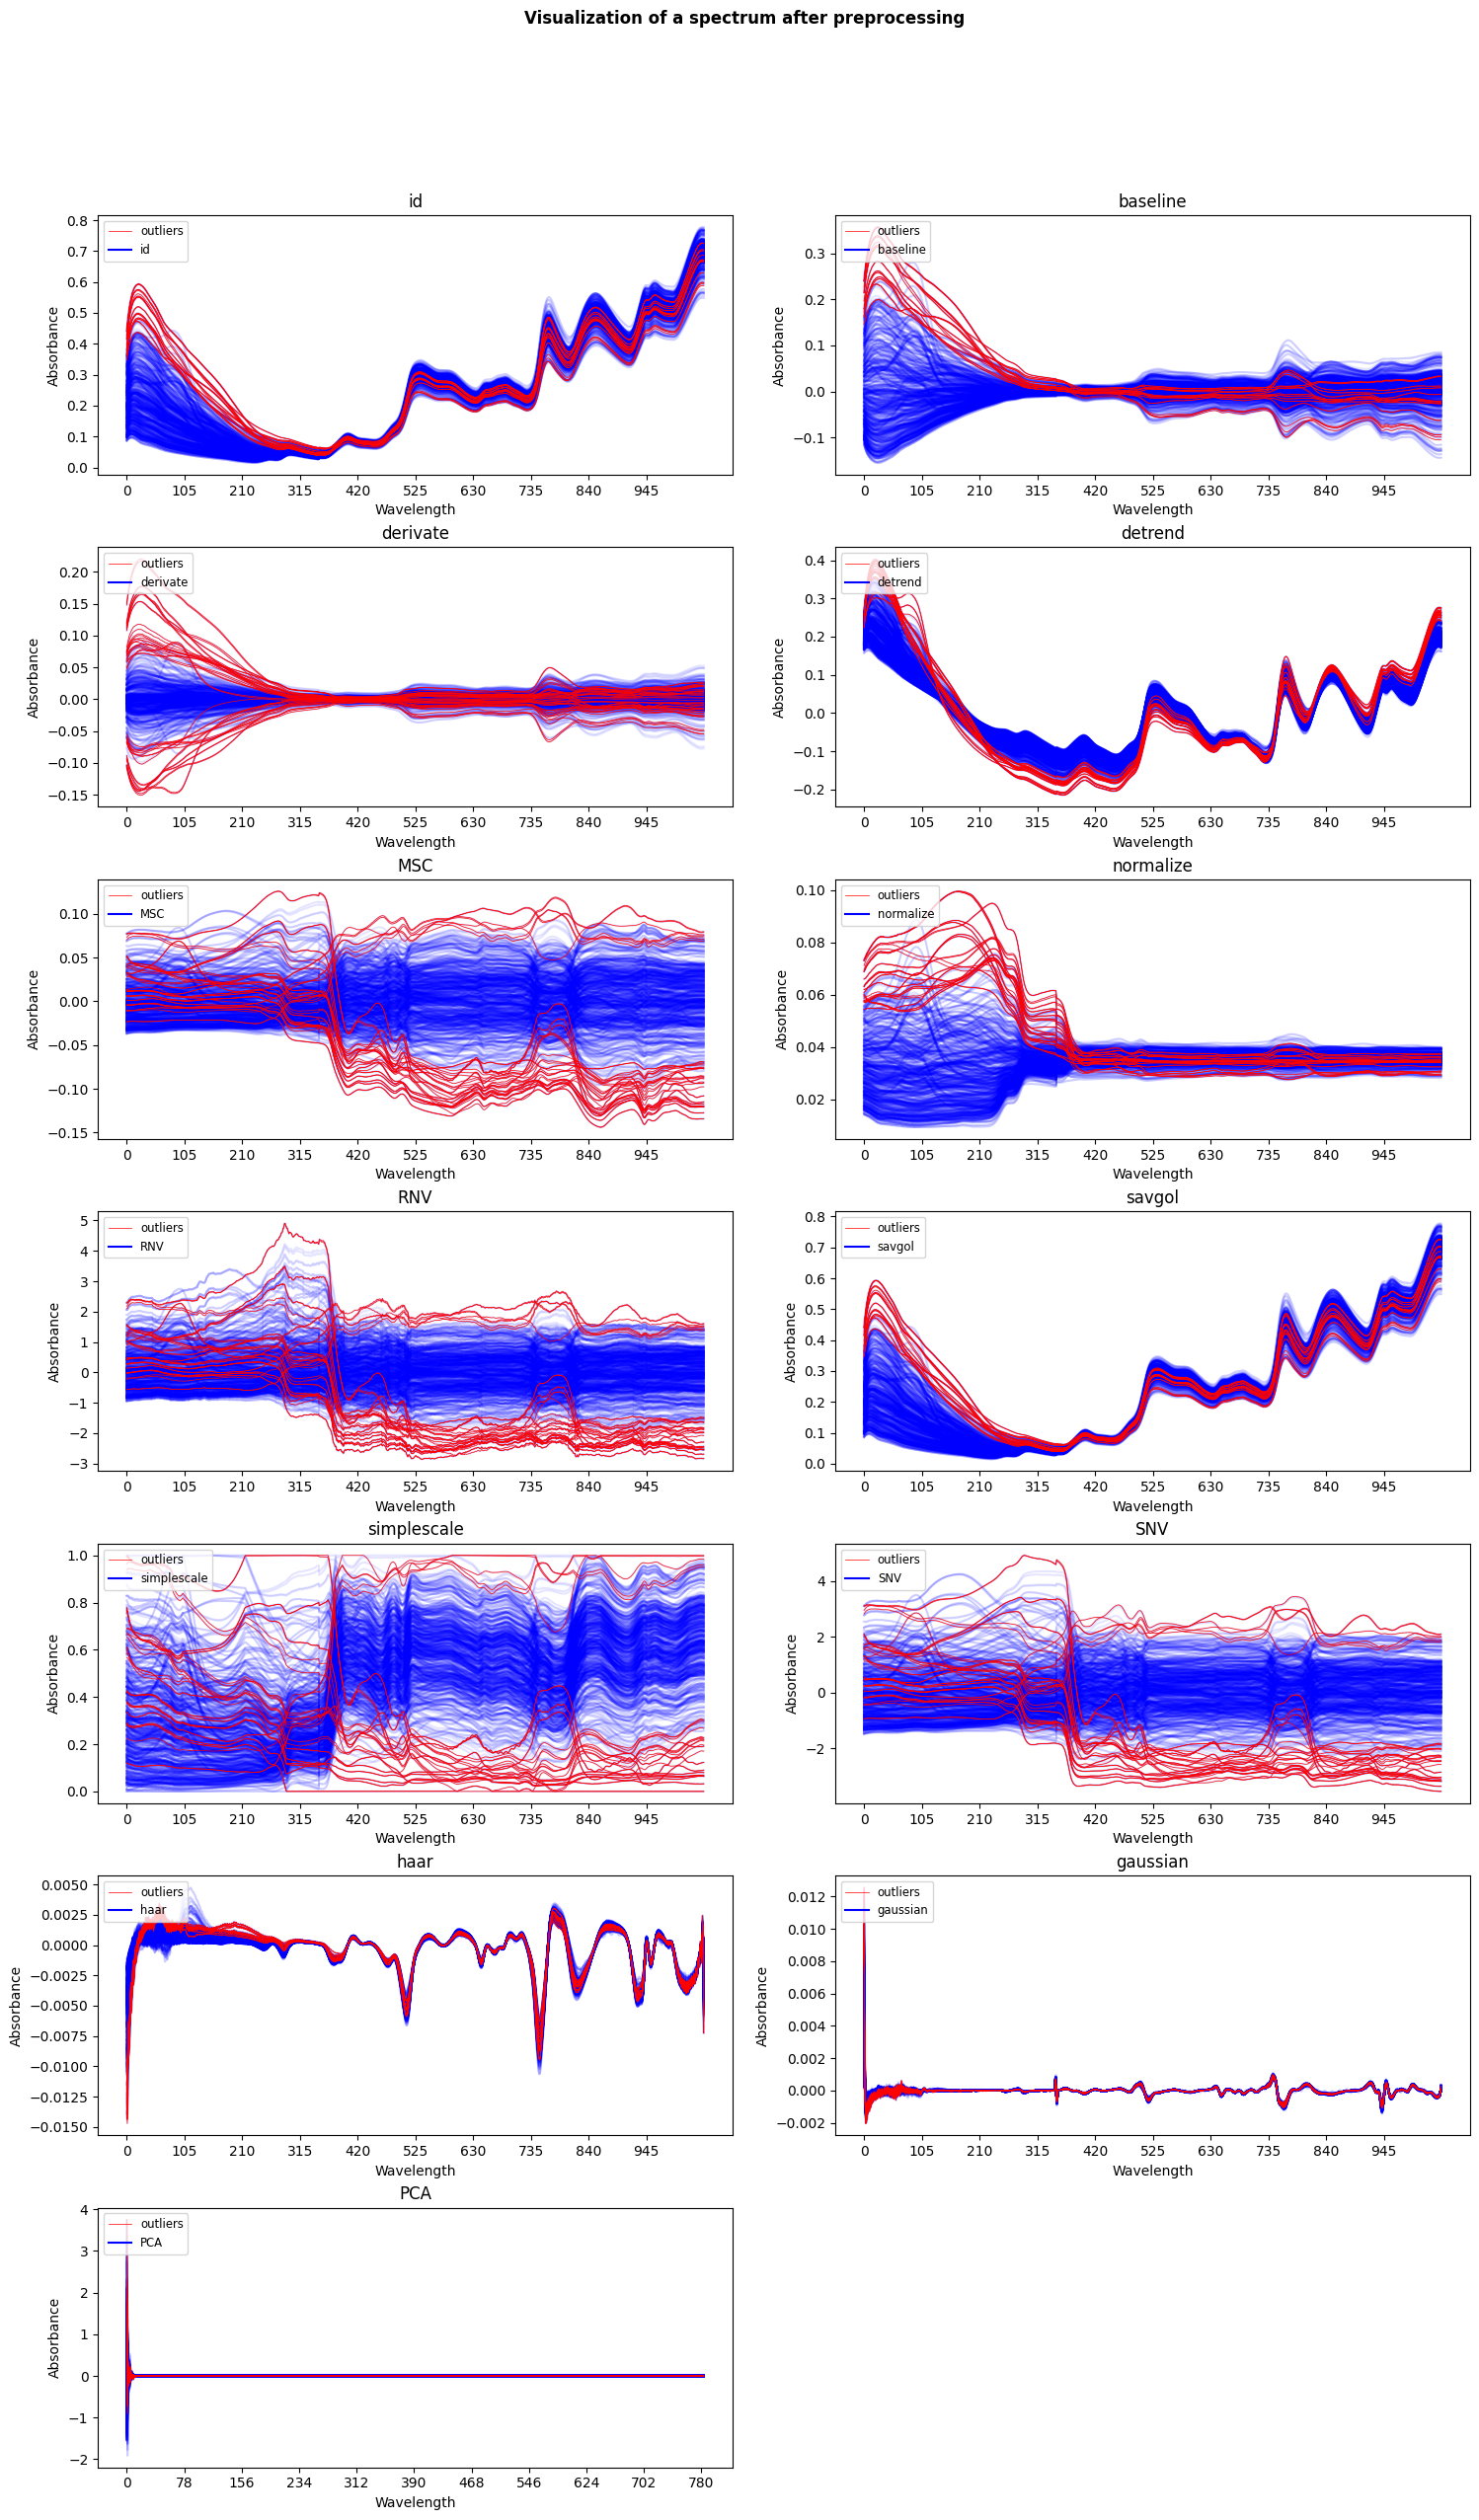

In [ ]:
def plot_spectra_outliers(X, dict_outliers, names, title='Visualization of the spectra with outliers', save_fig=False):
    if isinstance(X, pd.DataFrame):
        X = [X.values]
    elif isinstance(X, np.ndarray):
            X = [X]

    fig, axs = plt.subplots((len(X)+1)//2, 2, figsize=(15, 4*len(X)//2), dpi=100)
    axs = axs.flatten()
    for i, ax in enumerate(axs):
        if i >= len(X):
            ax.axis('off')
        else:
            name = names[i]
            dataset = X[i]
            if isinstance(dataset, pd.DataFrame):
                 dataset = dataset.values
            outliers = dict_outliers[name]
            ax.set_title(name)
            ax.set_xlabel('Wavelength')
            ax.set_ylabel('Absorbance')
            ax.set_xticks(np.arange(0, dataset.shape[1], dataset.shape[1]//10))
            ax.plot(dataset.T, color='blue', alpha = 0.1)
            
            if len(outliers) > 0:
                ax.plot(dataset[outliers,:].T, color='red', linewidth=0.5)
                ax.plot([], [], color='red', label='outliers', linewidth=0.5)
            
            ax.plot([], [], color='blue', label=name)
            ax.legend(loc='upper left', fontsize='small')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title, fontweight='bold')
    
    # Save figure if required in the folder Figures/outliers_detection
    if save_fig: 
        fig.savefig("Figures/outliers_detection/PCA/%s_comp_dissimilarity.png" % data_source, dpi=300)
    plt.show()


# Plot the spectra
plot_spectra_outliers(list(transformed_datasets.values()),
                      dict_outliers = dict_outliers,
                      names = list(transformed_datasets.keys()),
                      title = 'Visualization of a spectra with outliers detected by the PCA method',
                      save_fig = True)

### Detection of outliers with Data Depth Theory

In [157]:
def diff_abs_j(X,j):
    N_T, n_x = X.shape

    # Compute the differences of a given absorbance by all other absorbances in the same column of the spectral dataset
    Q = np.tile(X[j,:], (N_T,1))
    X_2 = X - Q

    # Compute the norm 2 of each line of this matrix and then square it
    X_fin = np.square(np.linalg.norm(X_2, axis=0))

    return X_fin

def detect_outliers_DDT_ED(X, kM=2.0):
    if isinstance(X, pd.DataFrame):
        X = X.values

    N_T, n_x = X.shape

    # Compute the ED for all spectrum
    distances = np.array([diff_abs_j(X,j) for j in range(N_T)])
    R = np.linalg.norm(distances, axis=1, ord=1)
    ED = 1/N_T * np.sqrt(R)

    # Define a threshold and detect outliers
    threshold = kM * np.median(ED)
    mask = ED > threshold
    outliers_ind = np.where(mask)
    return list(outliers_ind[0])

def identify_mrs(X):
    if isinstance(X, pd.DataFrame): X = X.values
    N_T, n_x = X.shape
    sdiff = np.zeros(N_T)
    sequal = np.zeros(N_T)

    for j in range(N_T):
        for i in range(n_x):
            l1 = np.sum(X[:, i] > X[j, i])
            l2 = np.sum(X[:, i] == X[j, i])
            l3 = np.sum(X[:, i] < X[j, i])
            sdiff[j] += abs(l1 - l3)
            sequal[j] += l2

    min_sdiff = np.min(sdiff)
    candidates = np.where(sdiff == min_sdiff)[0]
    if len(candidates) > 1:
        max_sequal = sequal[candidates].max()
        mrs_index = candidates[sequal[candidates] == max_sequal][0]
    else:
        mrs_index = candidates[0]
    return mrs_index

In [158]:
dict_outliers = {}
for name, method in preprocessing:
    x = transformed_datasets[name]

    # Perform outliers detection with the DDT method
    outliers_ind = detect_outliers_DDT_ED(x, kM=2.0)
    
    # Store the extreme individuals in the dictionary
    dict_outliers[name] = outliers_ind

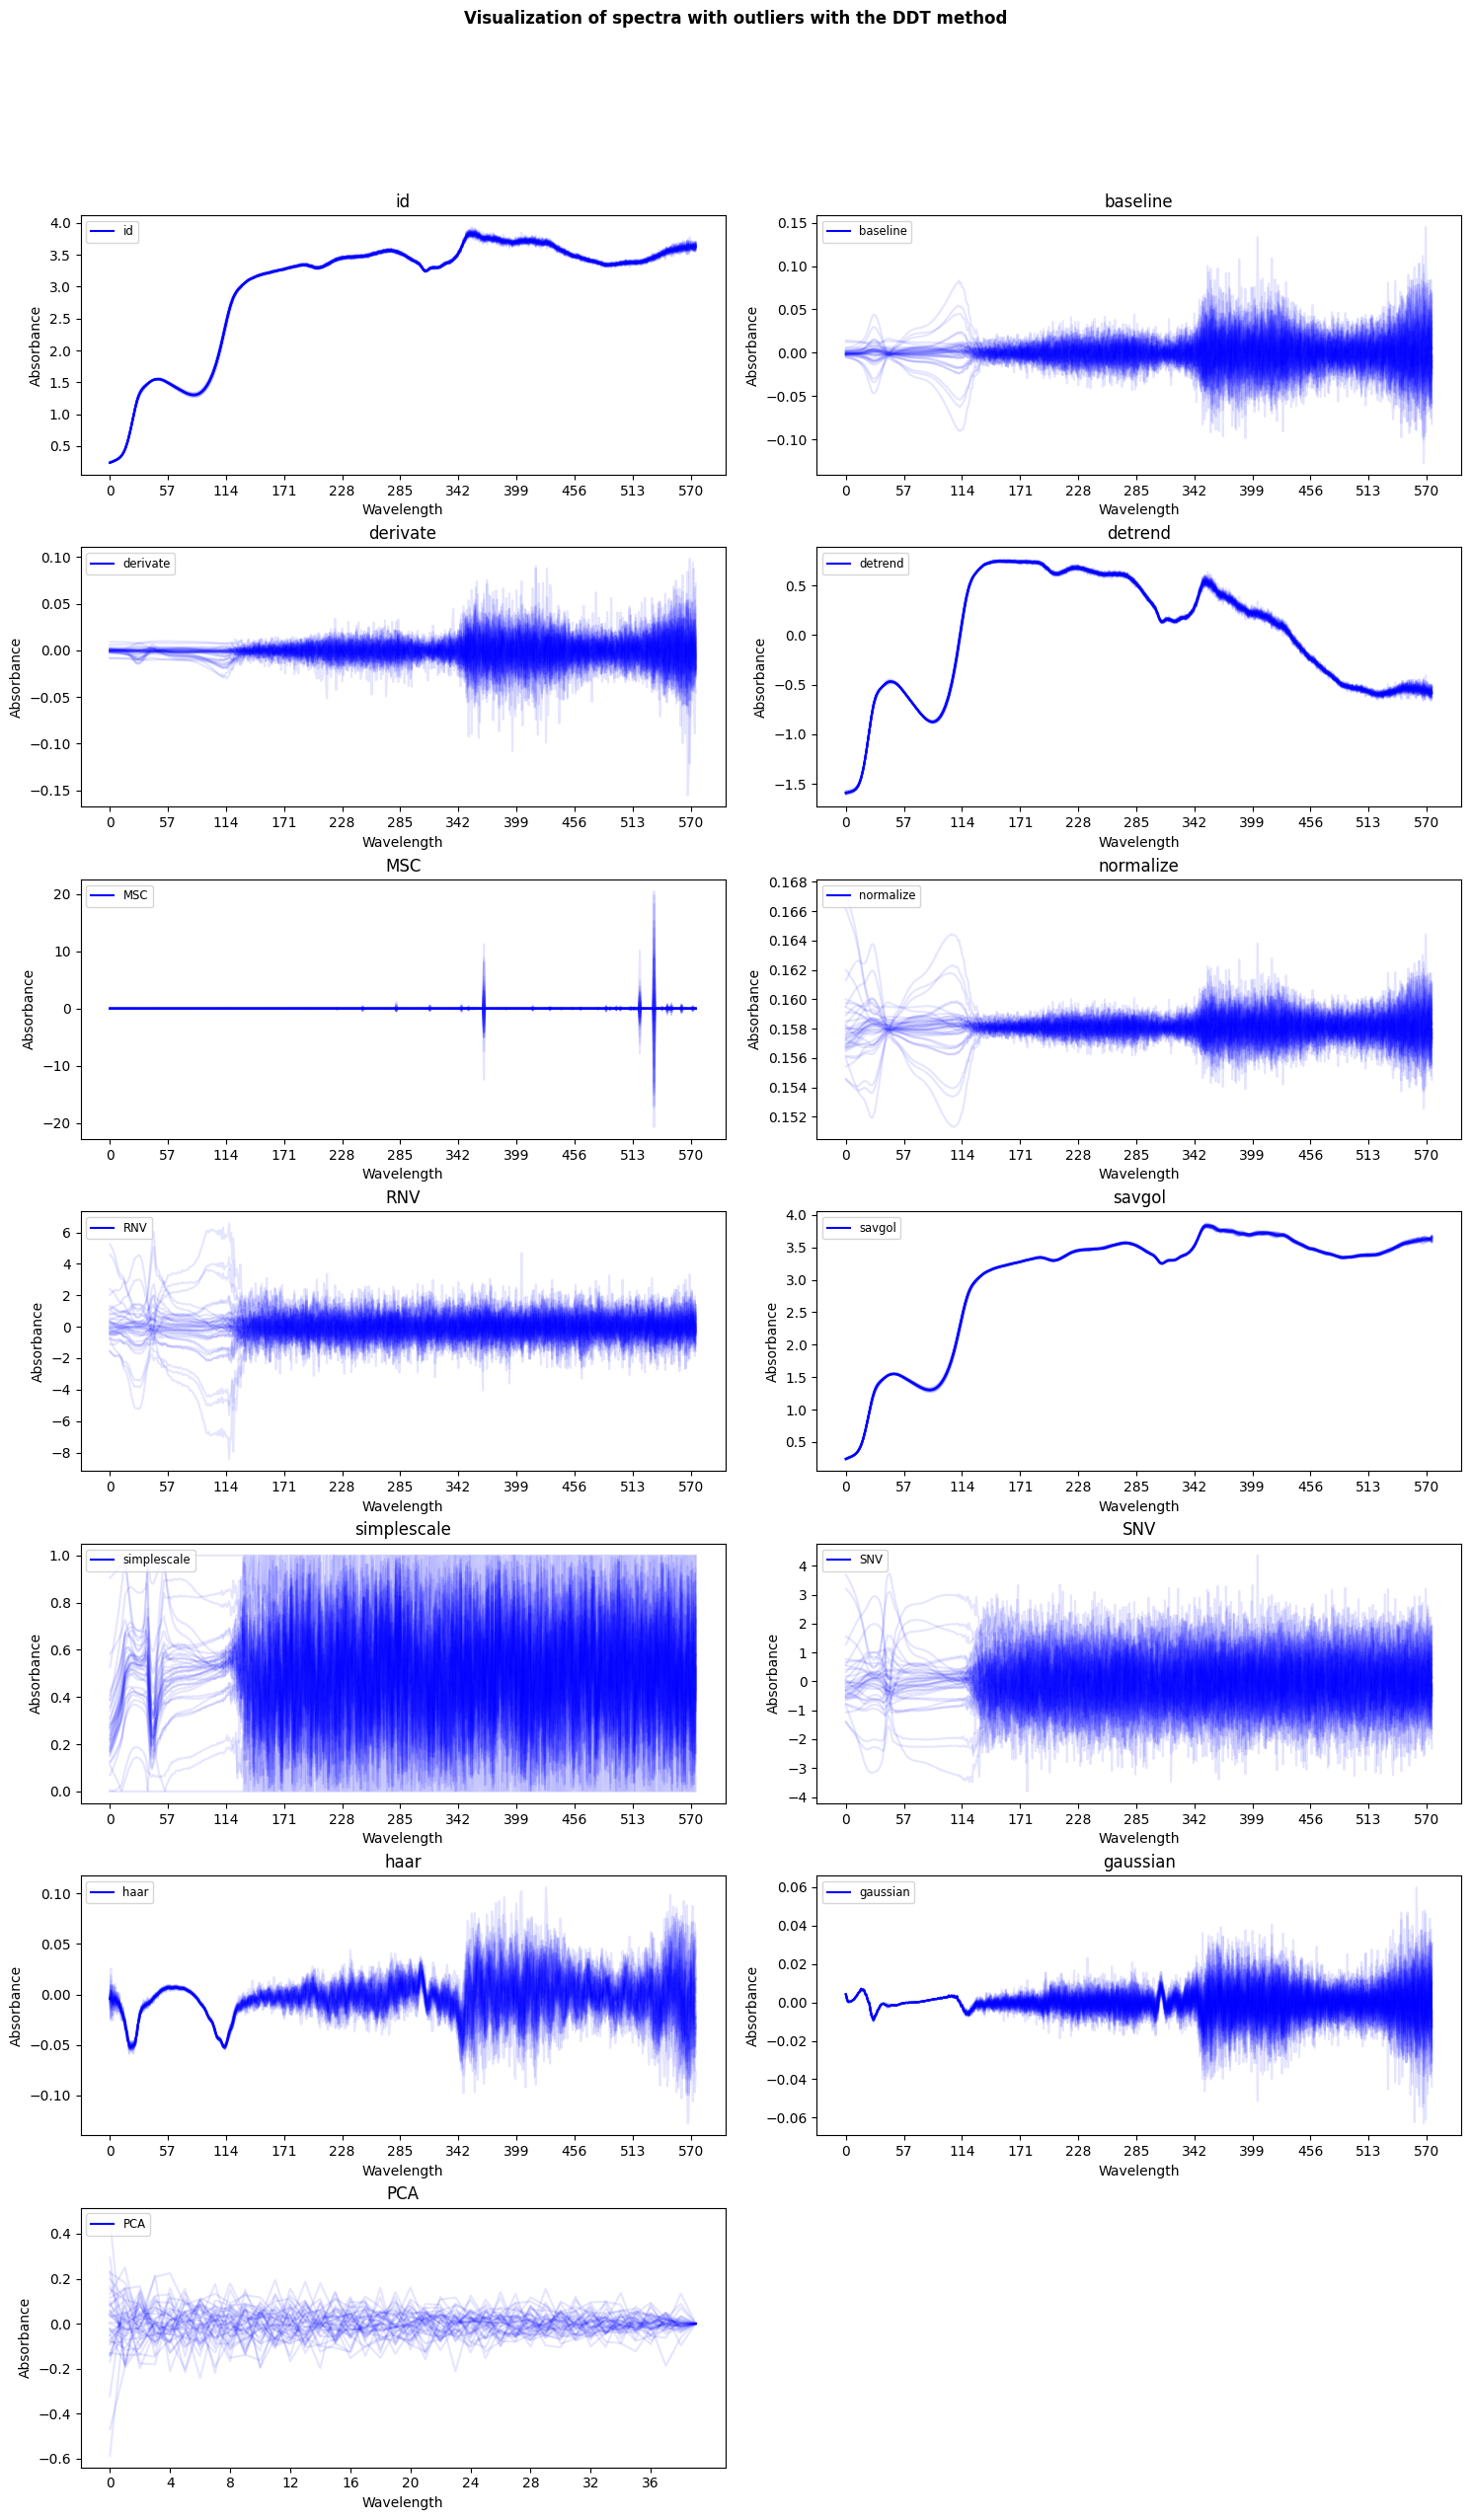

In [159]:
def plot_spectra_outliers(X, dict_outliers, names, title='Visualization of the spectra with outliers', save_fig=False):
    if isinstance(X, pd.DataFrame):
        X = [X.values]
    elif isinstance(X, np.ndarray):
            X = [X]

    fig, axs = plt.subplots((len(X)+1)//2, 2, figsize=(15, 4*len(X)//2), dpi=100)
    axs = axs.flatten()
    for i, ax in enumerate(axs):
        if i >= len(X):
            ax.axis('off')
        else:
            name = names[i]
            dataset = X[i]
            if isinstance(dataset, pd.DataFrame):
                 dataset = dataset.values
            outliers = dict_outliers[name]
            ax.set_title(name)
            ax.set_xlabel('Wavelength')
            ax.set_ylabel('Absorbance')
            ax.set_xticks(np.arange(0, dataset.shape[1], dataset.shape[1]//10))
            ax.plot(dataset.T, color='blue', alpha = 0.1)
            
            if len(outliers) > 0:
                ax.plot(dataset[outliers,:].T, color='red', linewidth=0.5)
                ax.plot([], [], color='red', label='outliers', linewidth=0.5)
            
            ax.plot([], [], color='blue', label=name)
            ax.legend(loc='upper left', fontsize='small')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title, fontweight='bold')
    
    # Save figure if required in the folder Figures/outliers_detection
    if save_fig: 
        fig.savefig("Figures/outliers_detection/DDT/%s_comp_dissimilarity.png" % data_source, dpi=300)
    plt.show()


# Plot the spectra
plot_spectra_outliers(list(transformed_datasets.values()),
                      dict_outliers = dict_outliers,
                      names = list(transformed_datasets.keys()),
                      title = 'Visualization of spectra with outliers with the DDT method',
                      save_fig = True)

#### Variant of this first method

In [151]:
def ddt_ddt_outlier_detection(X):
    N_T, n_x = X.shape
    outlier_mask = np.zeros(N_T, dtype=bool)

    for j in range(N_T):
        above_all = np.all(X[j, :] > X[np.arange(N_T) != j], axis=0).all()
        below_all = np.all(X[j, :] < X[np.arange(N_T) != j], axis=0).all()
        if above_all or below_all:
            outlier_mask[j] = True
    outliers_ind = list(np.where(outlier_mask)[0])
    return outliers_ind


In [161]:
dict_outliers = {}
for name, method in preprocessing:
    x = transformed_datasets[name]

    # Perform outliers detection with the DDT method
    outliers_ind = detect_outliers_DDT_ED(x, kM=2.0)

    # Add robustness to the process by performing another type of detection on non-outlier spectra
    x = np.delete(x, outliers_ind, axis=0)
    outliers_ind_else = ddt_ddt_outlier_detection(x)

    # Store the extreme individuals in the dictionary
    outliers_ind_all = list(np.concatenate((outliers_ind, outliers_ind_else), axis=0))
    dict_outliers[name] = [int(s) for s in outliers_ind_all]

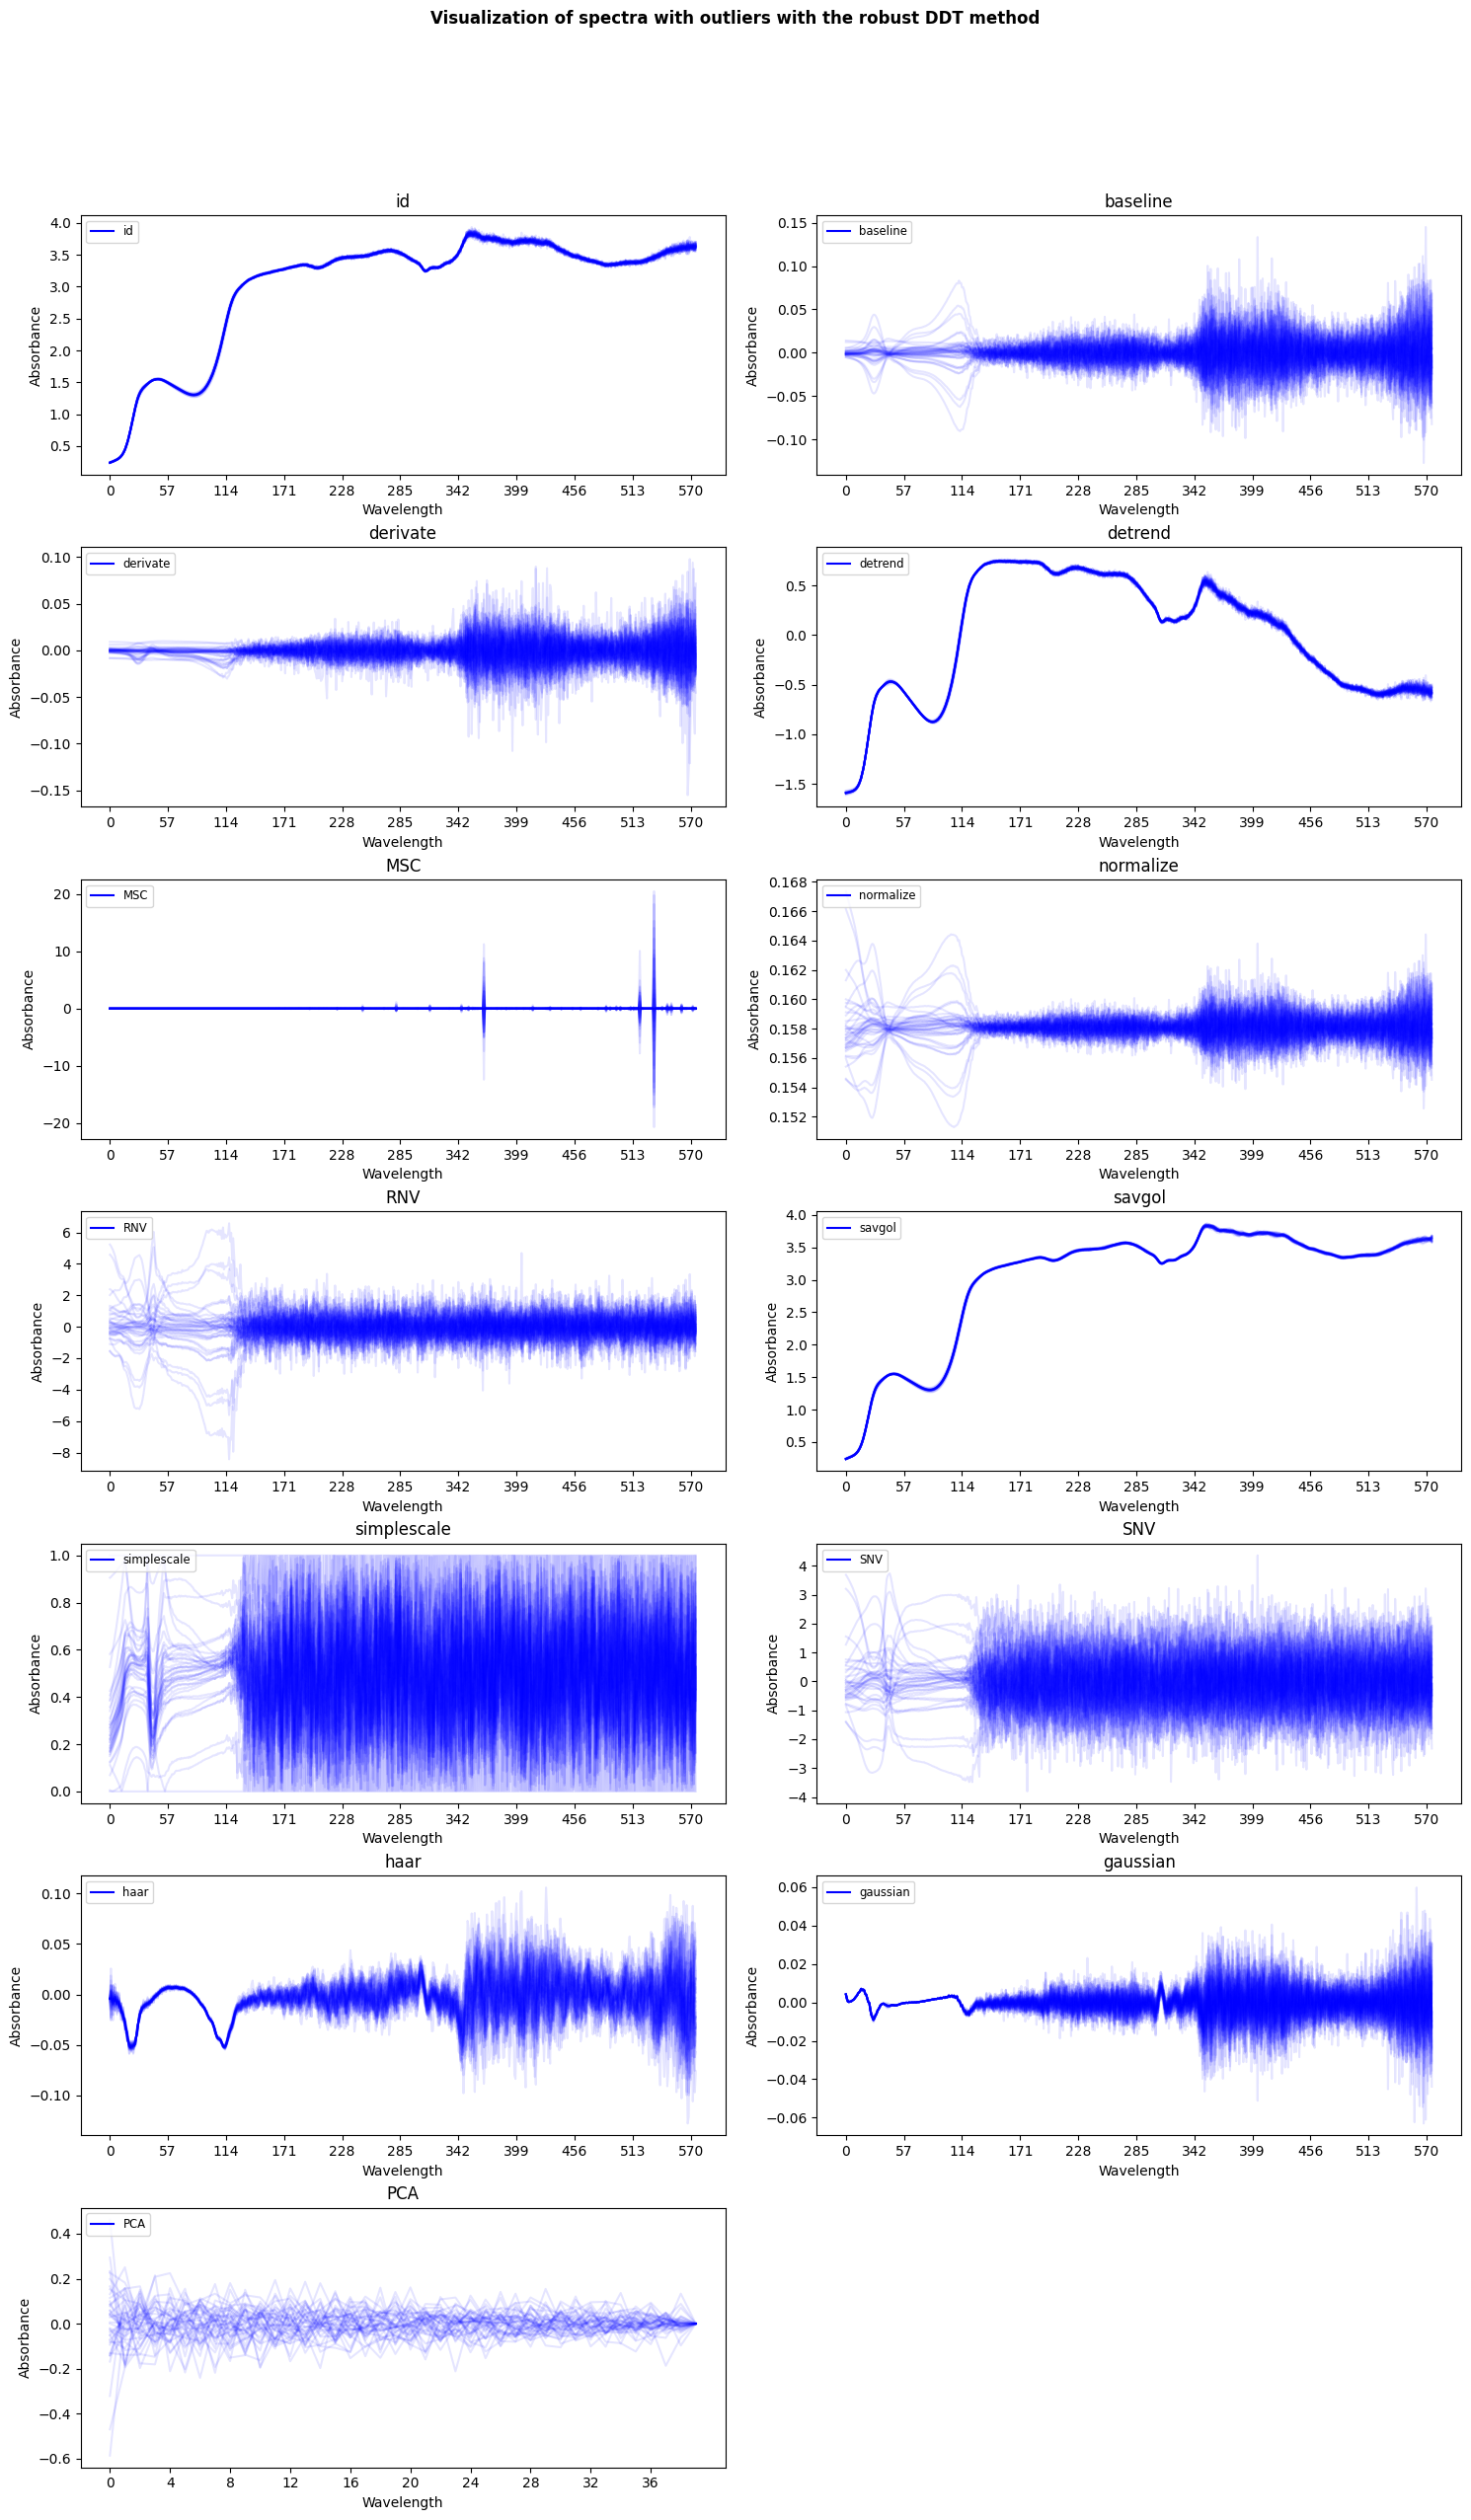

In [162]:
def plot_spectra_outliers(X, dict_outliers, names, title='Visualization of the spectra with outliers', save_fig=False):
    if isinstance(X, pd.DataFrame):
        X = [X.values]
    elif isinstance(X, np.ndarray):
            X = [X]

    fig, axs = plt.subplots((len(X)+1)//2, 2, figsize=(15, 4*len(X)//2), dpi=100)
    axs = axs.flatten()
    for i, ax in enumerate(axs):
        if i >= len(X):
            ax.axis('off')
        else:
            name = names[i]
            dataset = X[i]
            if isinstance(dataset, pd.DataFrame):
                 dataset = dataset.values
            outliers = dict_outliers[name]
            ax.set_title(name)
            ax.set_xlabel('Wavelength')
            ax.set_ylabel('Absorbance')
            ax.set_xticks(np.arange(0, dataset.shape[1], dataset.shape[1]//10))
            ax.plot(dataset.T, color='blue', alpha = 0.1)
            
            if len(outliers) > 0:
                ax.plot(dataset[outliers,:].T, color='red', linewidth=0.5)
                ax.plot([], [], color='red', label='outliers', linewidth=0.5)
            
            ax.plot([], [], color='blue', label=name)
            ax.legend(loc='upper left', fontsize='small')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title, fontweight='bold')
    
    # Save figure if required in the folder Figures/outliers_detection
    if save_fig: 
        fig.savefig("Figures/outliers_detection/DDT_robust/%s_comp_dissimilarity.png" % data_source, dpi=300)
    plt.show()


# Plot the spectra
plot_spectra_outliers(list(transformed_datasets.values()),
                      dict_outliers = dict_outliers,
                      names = list(transformed_datasets.keys()),
                      title = 'Visualization of spectra with outliers with the robust DDT method',
                      save_fig = True)

### Outliers detection with space transformation and spectral analysis